加载 `train.py` 训练得到的模型和特征统计量，构建预测数据并输出因子分数。

In [1]:
import numpy as np
import os
import train

In [2]:
def main(datasources, start_date, end_date):
    if not os.path.exists(train.MODEL_PATH):
        print(f"Model file not found: {train.MODEL_PATH}")
        train.train()
    table = datasources['bar1m']

    model, stats = train.load_model()
    data, meta, _ = train.build_data(
        start_date,
        end_date,
        table,
        stats=stats,
    )
    loader = train.DataLoader(
        train.WindowDataset(data, meta),
        batch_size=train.BATCH,
        shuffle=False,
        pin_memory=train.DEVICE == "cuda",
    )
    scores = train.infer(model, loader).numpy()

    result = meta[["date", "instrument"]].copy()
    result["score"] = scores
    return (
        result.replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["score"])
        .drop_duplicates(["date", "instrument"])
        .reset_index(drop=True)
    )

2026-08-04 10:39:50,753 INFO 构建推理数据 2024-01-01~2024-12-31 source=bigalpha_2026_stock_bar1m


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

查询并构建时间分片:   0%|          | 0/25 [00:00<?, ?片/s]

2026-08-04 10:39:59,526 INFO 2024-01-02~2024-01-15 raw=2,395,920 windows=9,983/10,000 labels=10,000/10,000 elapsed=2.6s
2026-08-04 10:40:02,336 INFO 2024-01-16~2024-01-29 raw=2,398,320 windows=9,993/10,000 labels=10,000/10,000 elapsed=2.8s
2026-08-04 10:40:05,396 INFO 2024-01-30~2024-02-20 raw=2,399,520 windows=9,998/10,000 labels=10,000/10,000 elapsed=3.1s
2026-08-04 10:40:08,569 INFO 2024-02-21~2024-03-05 raw=2,400,000 windows=10,000/10,000 labels=10,000/10,000 elapsed=3.2s
2026-08-04 10:40:11,675 INFO 2024-03-06~2024-03-19 raw=2,396,640 windows=9,986/10,000 labels=10,000/10,000 elapsed=3.1s
2026-08-04 10:40:14,773 INFO 2024-03-20~2024-04-02 raw=2,400,000 windows=10,000/10,000 labels=10,000/10,000 elapsed=3.1s
2026-08-04 10:40:18,193 INFO 2024-04-03~2024-04-18 raw=2,400,000 windows=10,000/10,000 labels=10,000/10,000 elapsed=3.4s
2026-08-04 10:40:21,331 INFO 2024-04-19~2024-05-07 raw=2,396,880 windows=9,987/10,000 labels=10,000/10,000 elapsed=3.1s
2026-08-04 10:40:24,468 INFO 2024-05-

标准化有效窗口:   0%|          | 0/15 [00:00<?, ?块/s]

2026-08-04 10:41:09,109 INFO 构建完成 data_shape=(242000, 240, 14) dates=242 samples=242,000 valid=241,664 masked=336 elapsed=78.4s
2026-08-04 10:41:09,110 INFO 覆盖度最差 date=2024-05-28 valid=986/1,000 coverage=98.60%


模型推理:   0%|          | 0/237 [00:00<?, ?批/s]

        date instrument     score
0 2024-01-02  000006.SZ  0.536650
1 2024-01-02  000012.SZ  0.541030
2 2024-01-02  000016.SZ  0.535055
3 2024-01-02  000019.SZ  0.550104
4 2024-01-02  000025.SZ  0.519048
rows=241664, dates=2024-01-02 00:00:00~2024-12-31 00:00:00
2026-08-04 10:41:20 [warning  ] bigalpha_eval._latest version='fake-v4' (local compatibility)
2026-08-04 10:41:20 [info     ] bigalpha_eval.v4 开始运行 ..      
2026-08-04 10:41:20 [info     ] 未提供因子池，只进行单因子分析               
2026-08-04 10:41:20 [info     ] 因子列名不为 factor, 自动重命名          
2026-08-04 10:41:20 [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
2026-08-04 10:41:21 [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
2026-08-04 10:41:21 [info     ] ========== 数据检查 ==========    
2026-08-04 10:41:21 [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
2026-08-04 10:41:21 [info     ] 通过：唯一性检查                      
2026-08-04 10:41:21 [info     ] 通过：factor 有限值检查（禁止 inf/-inf）  
2026-08-04 

时段,IC
2024-01-15~2024-02-08,0.0320
2024-09-24~2024-10-08,0.0566

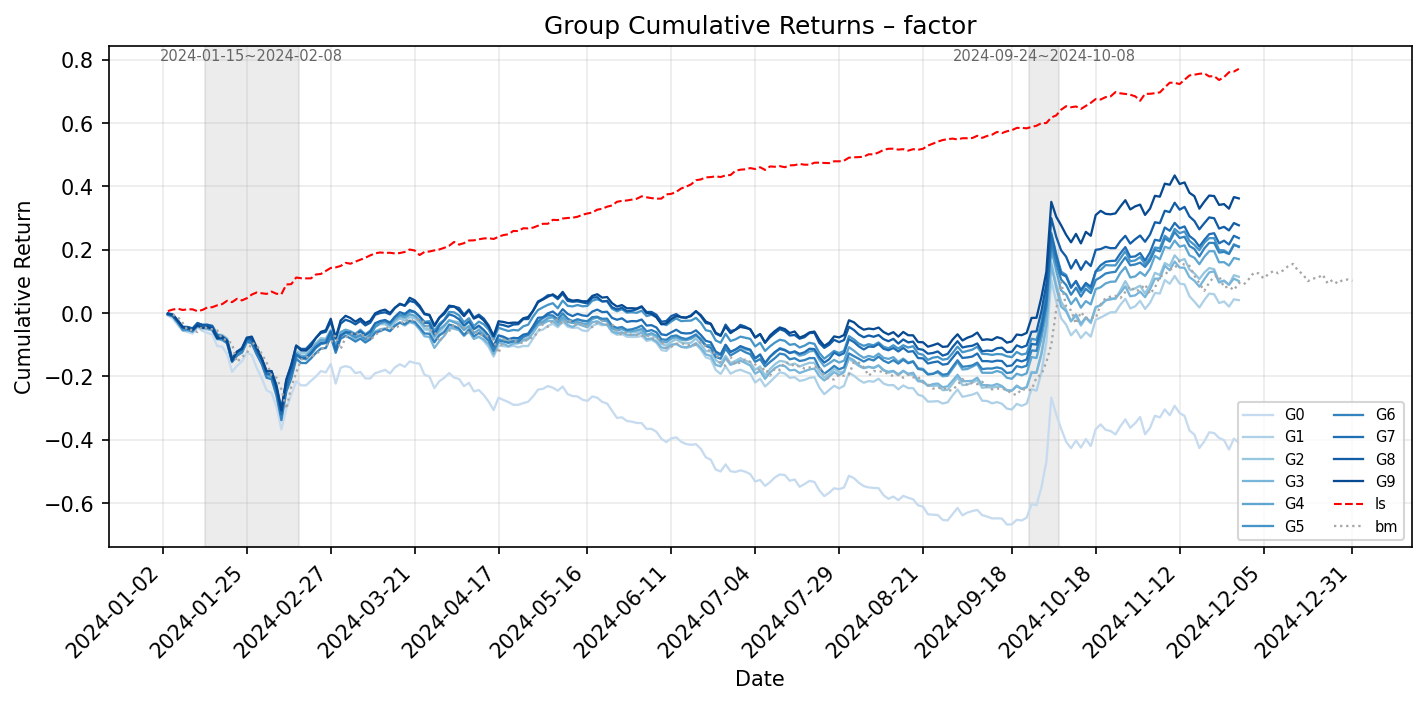
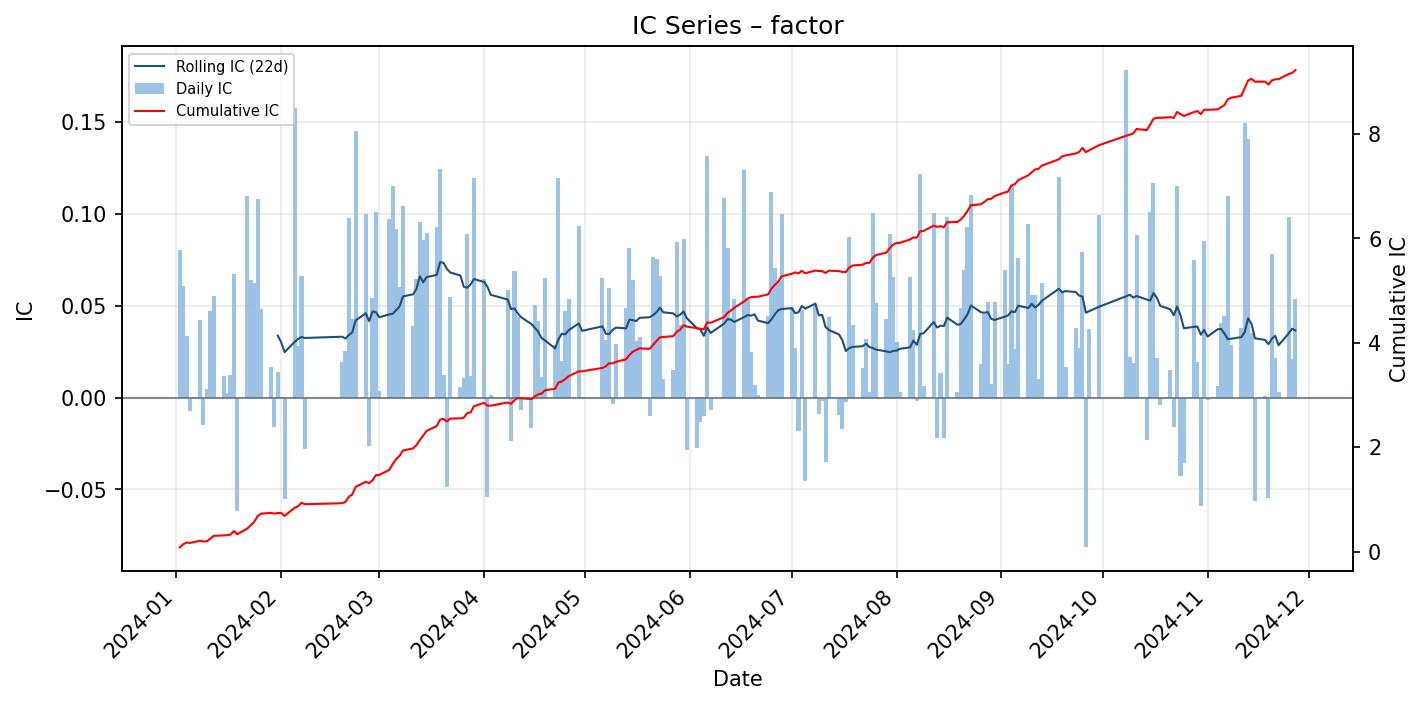
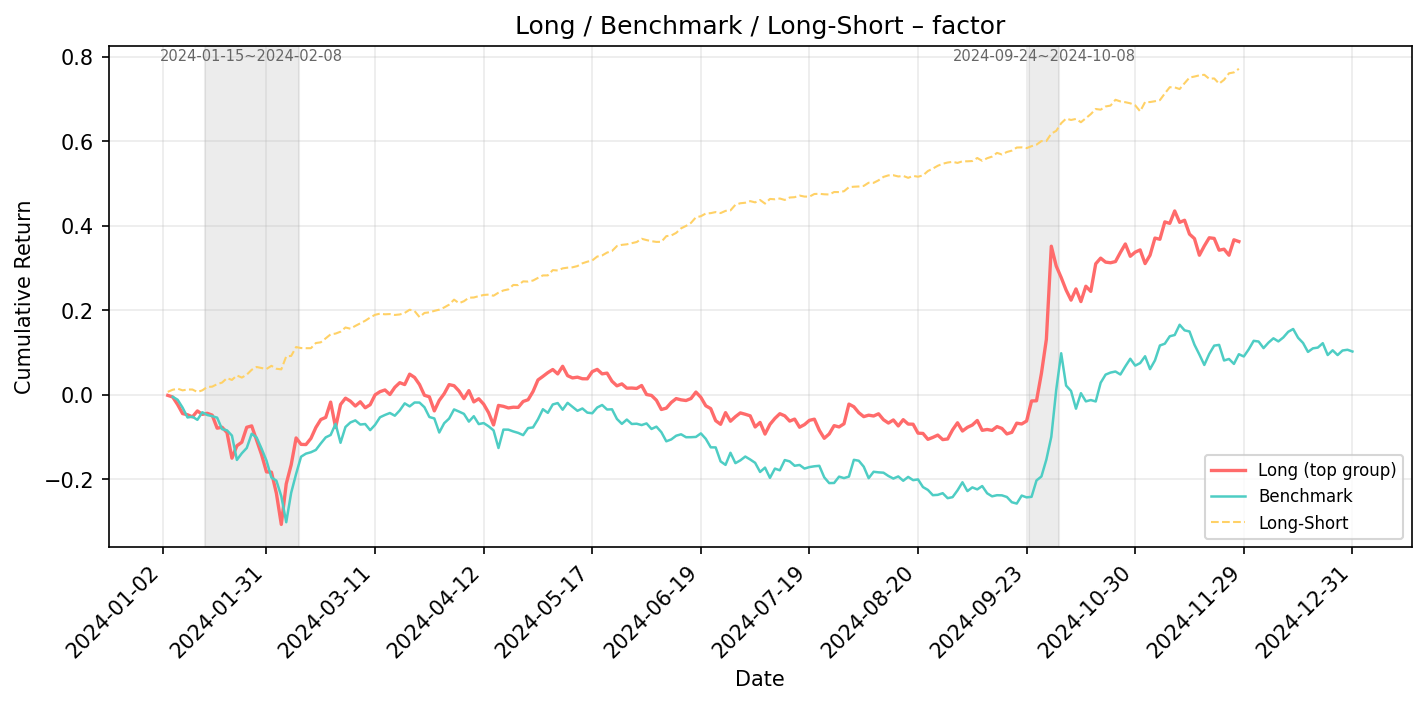
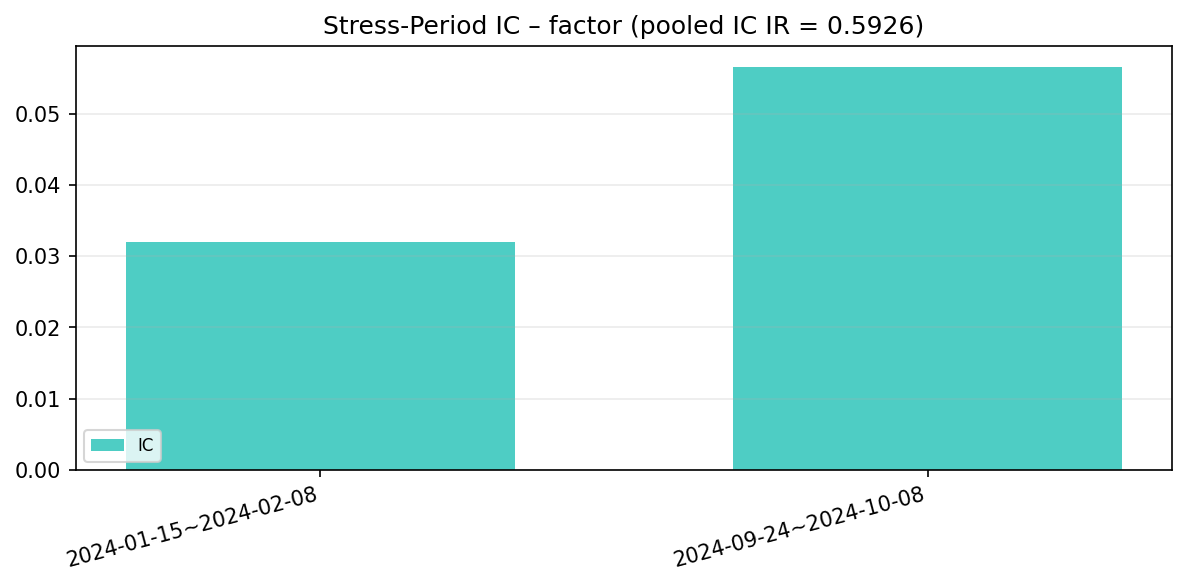
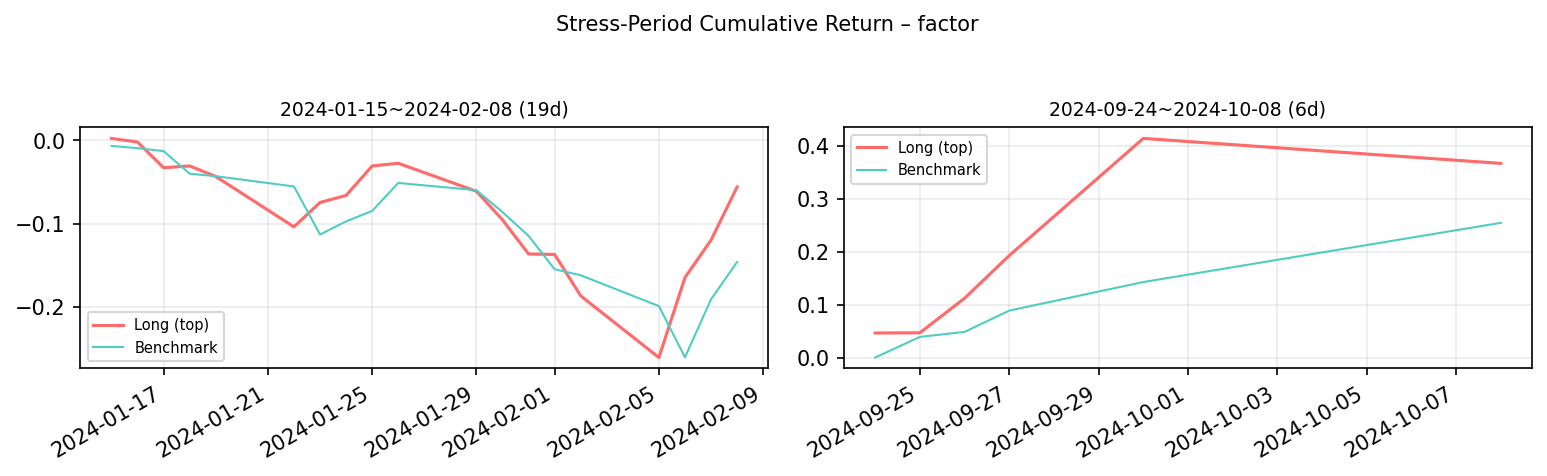

2026-08-04 10:41:24 [warning  ] 未传入因子池，跳过因子池回归检验              
2026-08-04 10:41:25 [info     ] bigalpha_eval.v4 运行完成 [4.084s].


In [3]:
if __name__ == "__main__":
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01"
    end_date = "2024-12-31"
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())
    print(
        f"rows={len(score_data)}, "
        f"dates={score_data['date'].min()}~{score_data['date'].max()}"
    )
    from bigmodule import M 

    result = M.bigalpha_eval._latest(
        factor_data=score_data,
        show=True,
    )